https://chatgpt.com/share/69bc1e8d-7c80-800d-bb9d-c5379cd07eee

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [71]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score, mean_squared_error

from sklearn.datasets import make_regression

In [72]:
 X,y = make_regression(n_samples=100,n_features=1,n_informative=1,n_targets=1,noise=20,random_state=13)

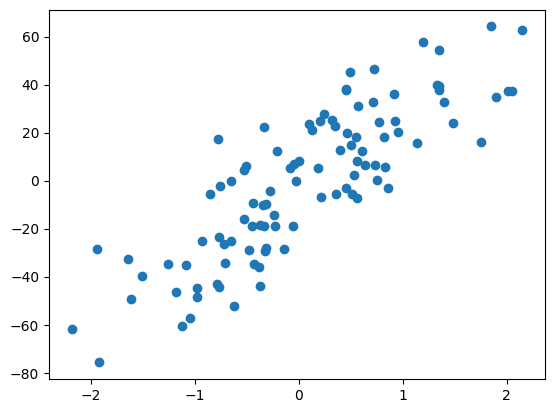

In [73]:
plt.scatter(X,y)

In [74]:
lr = LinearRegression()

In [75]:
lr.fit(X,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [80]:
print(lr.coef_)
print(lr.intercept_)

[27.82809103]
-2.29474455867698


In [98]:
y_pred = lr.predict(X)

In [99]:
r2_score(y,y_pred)

0.7035182396294911

In [88]:
R = Ridge(alpha=10)
R.fit(X,y)
print(R.coef_)
print(R.intercept_)

[24.9546267]
-2.1269130035235735


In [101]:
y_pred = R.predict(X)
r2_score(y,y_pred)

0.6960172225909294

In [90]:
R1 = Ridge(alpha=100)
R1.fit(X,y)
print(R1.coef_)
print(R1.intercept_)

[12.93442104]
-1.4248441496033308


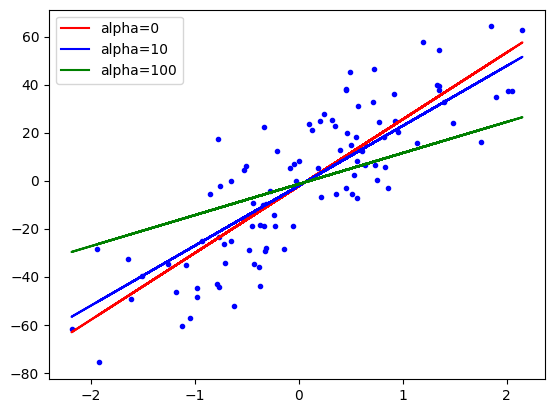

In [96]:
plt.plot(X,y,'b.')
plt.plot(X,lr.predict(X),'r',label="alpha=0")
plt.plot(X,R.predict(X),'b',label="alpha=10")
plt.plot(X,R1.predict(X),'g',label="alpha=100")
plt.legend()
plt.show()

## Ridge regression class 

In [135]:
class MeraRidge:
    def __init__(self,alpha=0.1):
        self.alpha = alpha
        self.m = None
        self.b = None

    def fit(self,X_train,y_train):
        num = 0
        den = 0

        for i in range(X_train.shape[0]):
            num += (y_train[i] - y_train.mean())*(X_train[i] - X_train.mean())
            den += ((X_train[i] - X_train.mean()) ** 2 )

        self.m = num / (den + self.alpha)
        self.b = y_train.mean() - self.m * X_train.mean()
        print(self.m,self.b)

    def predict(self,X_test):
        pass

In [136]:
mr = MeraRidge(10)

In [137]:
mr.fit(X,y)

[24.9546267] [-2.126913]
